#For dataset download

In [1]:
import torch
print(torch.version.cuda)          # Should show 12.6
print(torch.cuda.is_available())   # Should return True

12.6
True


C:\Users\prosh\AppData\Local\Temp\ipykernel_19152\574576979.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")


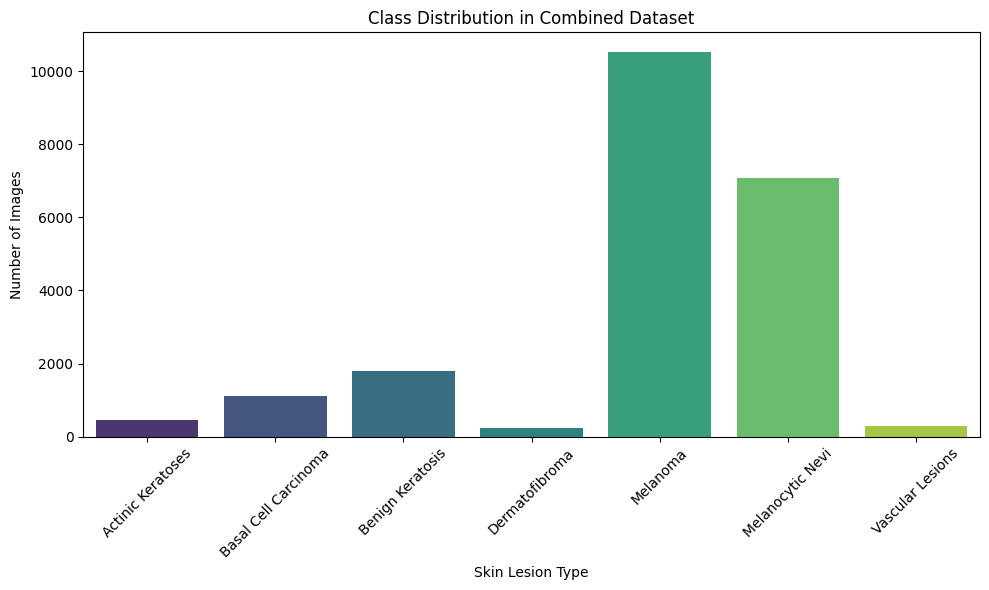

In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the dataset path
dataset_path = r'C:\profolders\Collage stuff\Sem 4 project\DL\Datasets\combined-dataset'

# Class labels mapping
class_labels = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions',
    'mel': 'Melanoma'
}

# Count the number of images in each class folder
class_counts = {class_labels[cls]: len(os.listdir(os.path.join(dataset_path, cls))) 
                for cls in os.listdir(dataset_path) if cls in class_labels}

# Plotting the class distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), palette="viridis")

plt.title('Class Distribution in Combined Dataset')
plt.xlabel('Skin Lesion Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()


In [18]:
import os
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split

# Paths
dataset_path = r'C:\profolders\Collage stuff\Sem 4 project\DL\Datasets\combined-dataset'

# Constants
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 16

# Class labels mapping (folder names)
class_labels = {
    'akiec': 'Actinic Keratoses',
    'bcc': 'Basal Cell Carcinoma',
    'bkl': 'Benign Keratosis',
    'df': 'Dermatofibroma',
    'nv': 'Melanocytic Nevi',
    'vasc': 'Vascular Lesions',
    'mel': 'Melanoma'
}

# Collect all images and labels
image_paths = []
labels = []
for class_name in os.listdir(dataset_path):
    if class_name in ['mel', 'nv']:  # Exclude these classes
        continue  

    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):  # Ensure it's a folder
        for img_file in os.listdir(class_dir):
            if img_file.endswith(('.jpg', '.png', '.jpeg')):  # Only image files
                image_paths.append(os.path.join(class_dir, img_file))
                labels.append(class_name)  # Use folder name as label

# Encode labels as indices
unique_labels = sorted([cls for cls in class_labels.keys() if cls not in ['mel', 'nv']])  # Remove unwanted classes
label_to_idx = {label: idx for idx, label in enumerate(unique_labels)}
labels = [label_to_idx[label] for label in labels]  # Convert to indices

# Train-Validation-Test Split (70%-15%-15%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, random_state=42
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, random_state=42
)

# Custom Dataset
class SkinLesionDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")  # Convert to RGB
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Transformations with On-the-Fly Resizing
basic_transform = transforms.Compose([
    transforms.RandomRotation(degrees=30),  # Rotate images randomly by ±30 degrees
    transforms.RandomHorizontalFlip(p=0.5),  # Flip images horizontally with 50% chance
    transforms.RandomVerticalFlip(p=0.3),  # Flip vertically with 30% chance
    #transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # Adjust color
    #transforms.RandomAffine(degrees=30, translate=(0.1, 0.1), shear=10), # Apply affine transformations
    transforms.Resize((128, 128)),  # Resize images dynamically
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1, 1] for GANs
])

# Create datasets
train_dataset = SkinLesionDataset(train_paths, train_labels, transform=basic_transform)
val_dataset = SkinLesionDataset(val_paths, val_labels, transform=basic_transform)
test_dataset = SkinLesionDataset(test_paths, test_labels, transform=basic_transform)

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print Dataset Sizes
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")


Train samples: 2706
Validation samples: 580
Test samples: 580


In [6]:
def dice_coefficient(pred, target, smooth=1e-5):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target, smooth=1e-5):
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return (intersection + smooth) / (union + smooth)

def pixel_accuracy(pred, target):
    pred = pred.view(-1)
    target = target.view(-1)
    correct = (pred == target).sum().item()
    total = target.size(0)
    return correct / total


In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import glob
import torchvision.utils as vutils
import torchvision.transforms as transforms
from PIL import Image

# Hyperparameters
latent_dim = 100
num_classes = 5  # 5 classes after excluding 'mel' and 'nv'
image_size = 128
batch_size = 64
lr = 0.0002
num_epochs = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class mapping (excluding 'mel' and 'nv')
class_to_idx = {'bkl': 0, 'bcc': 1, 'akiec': 2, 'vasc': 3, 'df': 4}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Output directory for generated images
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# Generator class
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, latent_dim // 2)
        self.model = nn.Sequential(
            nn.Linear(latent_dim + (latent_dim // 2), 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, 3 * image_size * image_size), nn.Tanh()
        )
    
    def forward(self, noise, labels):
        label_embedding = self.label_embedding(labels)
        input_vector = torch.cat((noise, label_embedding), dim=1)
        return self.model(input_vector).view(-1, 3, image_size, image_size)

# Discriminator class
class Discriminator(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.label_embedding = nn.Embedding(num_classes, latent_dim // 2)
        self.model = nn.Sequential(
            nn.Linear(3 * image_size * image_size + (latent_dim // 2), 1024), nn.LeakyReLU(0.2),
            nn.Linear(1024, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, img, labels):
        img_flat = img.view(img.size(0), -1)
        label_embedding = self.label_embedding(labels)
        input_vector = torch.cat((img_flat, label_embedding), dim=1)
        return self.model(input_vector)

# Initialize models and optimizers
generator = Generator(latent_dim, num_classes).to(device)
discriminator = Discriminator(num_classes).to(device)

def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

generator.apply(weights_init)
discriminator.apply(weights_init)

# Loss and Optimizers
criterion = nn.BCEWithLogitsLoss()
optimizer_G = optim.AdamW(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.AdamW(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

def save_checkpoint(epoch, g_loss, d_loss):
    checkpoint_dir = 'checkpoints'
    os.makedirs(checkpoint_dir, exist_ok=True)
    
    latest_checkpoint_path = os.path.join(checkpoint_dir, 'gan_checkpoint_latest.pth')
    
    if epoch % 10 == 0:
        existing_checkpoints = glob.glob(os.path.join(checkpoint_dir, 'gan_checkpoint_epoch_*.pth'))
        for ckpt in existing_checkpoints:
            ckpt_epoch = int(ckpt.split('_')[-1].split('.')[0])
            if ckpt_epoch % 200 != 0:
                os.remove(ckpt)
        
        numbered_checkpoint_path = os.path.join(checkpoint_dir, f'gan_checkpoint_epoch_{epoch}.pth')
        torch.save({
            'epoch': epoch,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict': optimizer_G.state_dict(),
            'optimizer_D_state_dict': optimizer_D.state_dict(),
            'g_loss': g_loss.item(),
            'd_loss': d_loss.item()
        }, numbered_checkpoint_path)
        print(f"Saved checkpoint at epoch {epoch} to {numbered_checkpoint_path}")
    
    torch.save({
        'epoch': epoch,
        'generator_state_dict': generator.state_dict(),
        'discriminator_state_dict': discriminator.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
        'g_loss': g_loss.item(),
        'd_loss': d_loss.item()
    }, latest_checkpoint_path)

def save_generated_images(epoch):
    generator.eval()
    with torch.no_grad():
        for class_idx in range(num_classes):
            noise = torch.randn(1, latent_dim).to(device)
            label = torch.tensor([class_idx], dtype=torch.long).to(device)
            fake_image = generator(noise, label).cpu()
            fake_image = (fake_image + 1) / 2  # Denormalize to [0, 1]
            vutils.save_image(fake_image, os.path.join(output_dir, f'epoch_{epoch}_class_{idx_to_class[class_idx]}.png'))
    generator.train()

g_losses = []
d_losses = []

for epoch in range(num_epochs):
    for batch in train_loader:
        real_images, labels = batch[0].to(device), batch[1].to(torch.long).to(device)
        batch_size = real_images.size(0)

        optimizer_D.zero_grad()
        noise = torch.randn(batch_size, latent_dim).to(device)
        fake_images = generator(noise, labels)
        
        real_loss = criterion(discriminator(real_images, labels), torch.full((batch_size, 1), 0.9, device=device))
        fake_loss = criterion(discriminator(fake_images.detach(), labels), torch.full((batch_size, 1), 0.1, device=device))
        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        optimizer_G.zero_grad()
        g_loss = criterion(discriminator(fake_images, labels), torch.full((batch_size, 1), 0.9, device=device))
        g_loss.backward()
        optimizer_G.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())
    save_checkpoint(epoch + 1, g_loss, d_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")
    
    if (epoch + 1) % 50 == 0:
        save_generated_images(epoch + 1)

print("Finished Training")


Epoch [1/1000] | D Loss: 1.1367 | G Loss: 1.0513
Epoch [2/1000] | D Loss: 0.8130 | G Loss: 2.3083
Epoch [3/1000] | D Loss: 0.9433 | G Loss: 0.9390
Epoch [4/1000] | D Loss: 0.9505 | G Loss: 2.6284
Epoch [5/1000] | D Loss: 1.9015 | G Loss: 1.0641
Epoch [6/1000] | D Loss: 0.9190 | G Loss: 0.6137
Epoch [7/1000] | D Loss: 0.8107 | G Loss: 1.8821
Epoch [8/1000] | D Loss: 0.8401 | G Loss: 1.4088
Epoch [9/1000] | D Loss: 0.7417 | G Loss: 4.0129
Saved checkpoint at epoch 10 to checkpoints\gan_checkpoint_epoch_10.pth
Epoch [10/1000] | D Loss: 1.3394 | G Loss: 0.7629
Epoch [11/1000] | D Loss: 1.6531 | G Loss: 1.4654
Epoch [12/1000] | D Loss: 0.8528 | G Loss: 1.6565
Epoch [13/1000] | D Loss: 1.0617 | G Loss: 1.2213
Epoch [14/1000] | D Loss: 1.1839 | G Loss: 1.5948
Epoch [15/1000] | D Loss: 0.9360 | G Loss: 2.2244
Epoch [16/1000] | D Loss: 1.6346 | G Loss: 4.2207
Epoch [17/1000] | D Loss: 1.2480 | G Loss: 1.0307
Epoch [18/1000] | D Loss: 1.0590 | G Loss: 2.7288
Epoch [19/1000] | D Loss: 1.1935 | G 

KeyboardInterrupt: 

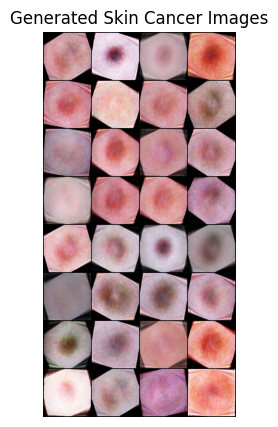

In [58]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

def generate_and_show_images(generator, num_images=32):
    generator.eval()  # Set generator to evaluation mode
    noise = torch.randn(num_images, latent_dim).to(device)

    # Generate random labels
    random_labels = torch.randint(0, num_classes, (num_images,)).to(device)

    # Generate images
    with torch.no_grad():
        fake_images = generator(noise, random_labels)

    # Denormalize images (optional, depending on your training process)
    fake_images = (fake_images + 1) / 2  # Scale from [-1, 1] to [0, 1]

    # Convert to CPU for visualization
    fake_images = fake_images.cpu()

    # Display images
    plt.figure(figsize=(10, 5))
    plt.axis("off")
    plt.title("Generated Skin Cancer Images")
    plt.imshow(
        np.transpose(vutils.make_grid(fake_images, nrow=4, padding=2, normalize=True), (1, 2, 0))
    )
    plt.show()

# Call function to visualize images
generate_and_show_images(generator)

In [62]:
import os
import matplotlib.pyplot as plt

# Create output directory if it doesn't exist
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

# Assuming you stored metrics in lists
epochs_range = range(len(d_losses))  # Ensure this matches your actual epochs

plt.figure(figsize=(9, 4))

# Discriminator Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, d_losses, label='D Loss', color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Discriminator Loss')
plt.legend()

# Generator Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, g_losses, label='G Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Generator Loss')
plt.legend()

plt.tight_layout()

# Save the figure
plot_path = os.path.join(output_dir, "loss_plot.png")
plt.savefig(plot_path)
plt.close()

print(f"Loss plot saved to {plot_path}")


Loss plot saved to output\loss_plot.png
